In [1]:
#Importing libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

#Loading dataset
dataset=load_dataset("lukebarousse/data_jobs")
df=dataset['train'].to_pandas()

#Cleaning data
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_IND=df[(df['job_location']=='India')&(df['job_title_short']=='Data Analyst')].copy()
df_DA_IND['month_no']=df_DA_IND['job_posted_date'].dt.month
df_DA_IND_explod=df_DA_IND.explode('job_skills')


In [3]:
df_pivot=df_DA_IND_explod.pivot_table(index='month_no',columns='job_skills',aggfunc='size',fill_value=0)
df_pivot.loc['Total']=df_pivot.sum()
df_pivot.sort_values(by='Total',axis=1,ascending=False,inplace=True)
df_pivot=df_pivot.drop('Total')


In [4]:
DA_month_tot=df_DA_IND.groupby('month_no').size()

In [5]:
df_percent=df_pivot.div(DA_month_tot/100,axis=0)

In [6]:
df_percent=df_percent.reset_index()
df_percent['job_posted_month']=df_percent['month_no'].apply(lambda x:pd.to_datetime(x,format='%m').strftime('%b'))
df_percent=df_percent.set_index('job_posted_month')
df_percent=df_percent.drop(columns='month_no')

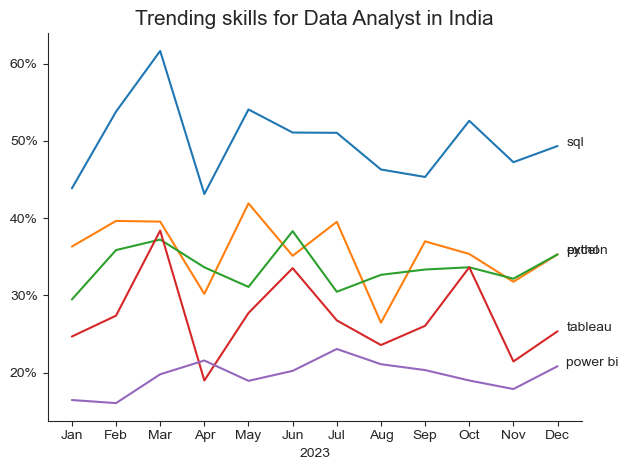

In [7]:
df_plot=df_percent.iloc[:,:5]

sns.set_style('ticks')
sns.lineplot(data=df_plot,dashes=False,palette='tab10',legend=False)
sns.despine()

plt.title('Trending skills for Data Analyst in India',fontsize=15)
plt.xlabel('2023')
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'{x:.0f}%'))
for i in range(5):
    plt.text(11.2,df_plot.iloc[-1,i],df_plot.columns[i])

plt.tight_layout()